In [1]:
import os
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import time
import tm
import tqdm
import copy
import sys
import datasetutils
plt.style.use('dark_background') # i prefer this color scheme but need to install. coment if not working

In [2]:
#import importlib
#importlib.reload(tm)

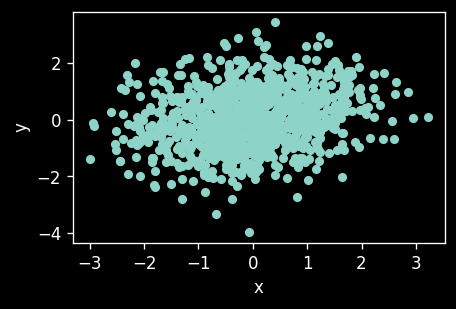

In [3]:
# 1 - CREATE DATA
# the idea is to create a dataframe with variables started with x and target returns started with y
# columns then can be x1, x_1, x2, xsomething ... and y1, y, y2, y_3
# index should be a datetime 
# this is the part where we spend most time researching :)
# lets generate some synthetic data 
n = 1000
x = np.random.normal(0, 1, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,1,n)
df1 = pd.DataFrame()
df1['x'] = x
df1['y'] = y
df1.index = pd.date_range('2000-01-01', freq = 'D', periods = n)
df1.plot.scatter('x', 'y')
plt.show()


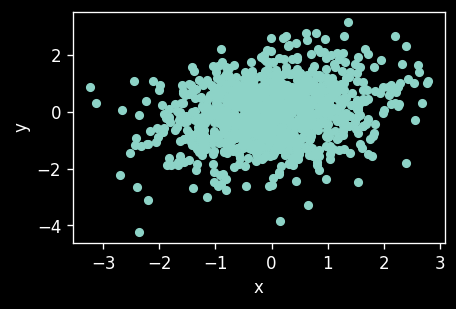

,y,x
2002-01-01,0.645306,-0.678932
2002-01-02,-0.526673,-1.679769
2002-01-03,-1.134062,-0.327860
2002-01-04,-1.449563,-0.285462
2002-01-05,1.392277,-0.981861
...,...,...
2004-09-22,1.213136,0.977908
2004-09-23,0.313138,2.194643
2004-09-24,0.961763,1.239784
2004-09-25,-0.905977,1.011790


In [4]:
# 1 - CREATE DATA
# the idea is to create a dataframe with variables started with x and target returns started with y
# columns then can be x1, x_1, x2, xsomething ... and y1, y, y2, y_3
# index should be a datetime 
# this is the part where we spend most time researching :)
# lets generate some synthetic data 
n = 1000
x = np.random.normal(0, 1, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,1,n)
df2 = pd.DataFrame()
df2['y'] = y
df2['x'] = x
df2.index = pd.date_range('2002-01-01', freq = 'D', periods = n)
df2.plot.scatter('x', 'y')
plt.show()
df2

In [15]:
# 2 - CREATE TM OBJECTS



dataset = tm.Dataset()
dataset.add('strat1', df1)
dataset.add('strat2', df2)

ensemble_model = tm.ensemble.InvVolEnsembleModel()
base_model = tm.base.LinRegr()
alloc = tm.allocation.Optimal(c = None)
model1 = tm.Model(base_model = base_model, allocation = alloc)    

model2 = tm.Model(base_model = base_model, allocation = alloc)    


master_models_map = [
        {'master_model':model1, 
         'apply_to':['strat1', 'strat2'], 
         'columns':['y','x']
        },
        {'master_model':model2, 
         'apply_to':['strat1'], 
         'columns':['y','x']
        },
    
        ] 

model_set = tm.ModelSet(ensemble_model = ensemble_model, master_models_map = master_models_map)     

model_set.estimate(dataset)
model_set.view()



******* ModelSet *******

EnsembleModel
Portfolio Weight for strat1 = 0.5005314371647074
Portfolio Weight for strat2 = 0.49946856283529256


-> For key strat1
* Model *
** Linear Regression **
Weights:  [0.08058953 0.23402008]
Variance:  0.9963715198492898


Weight norm:  0.38822967303821476
Weight mean:  0.06006191393307038



-> For key strat2
* Model *
** Linear Regression **
Weights:  [0.02296847 0.24065904]
Variance:  1.0003774101704532


Weight norm:  0.3906568214532127
Weight mean:  0.014886008713054562


*************************


In [12]:
# 3 - RUN CVBT
# this part is always the same and is easy
paths = tm.cvbt(
        dataset = dataset, 
        modelset = model_set,            
        n_paths = 5,
        k_folds = 4, 
        seq_path = False, 
        start_fold = 0, 
        burn_fraction = 0.1, 
        min_burn_points = 3,
        view_after_estimate = False
        )


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 31.78it/s]


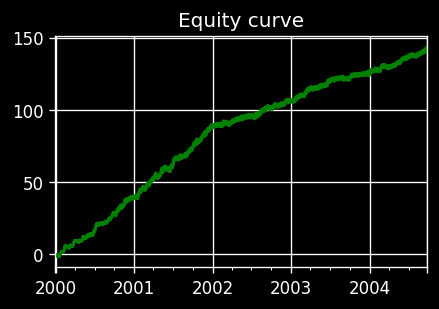

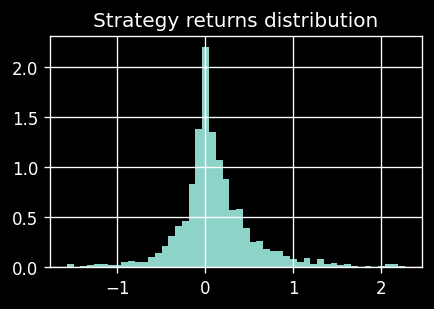

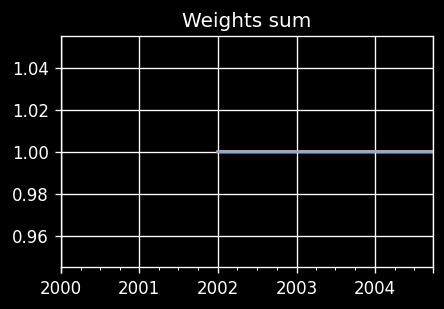

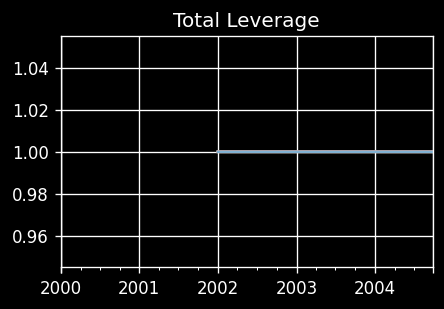

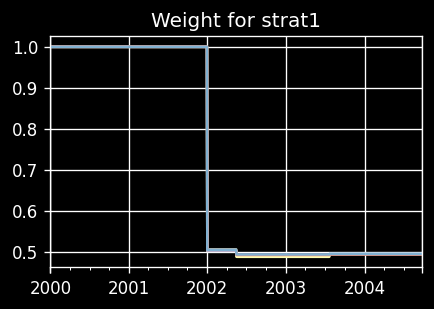

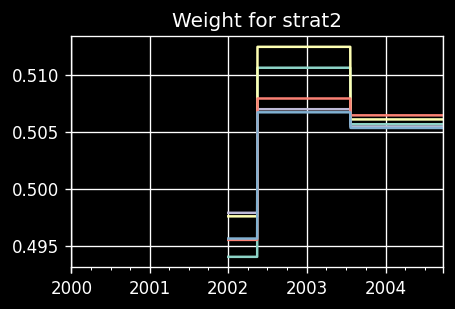

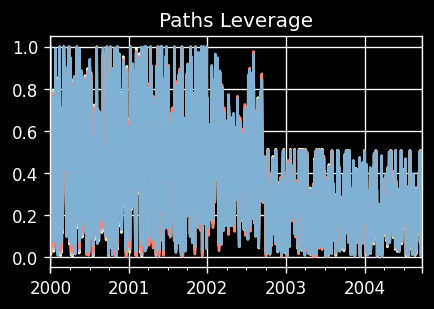

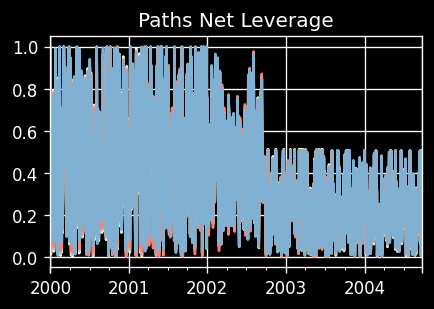

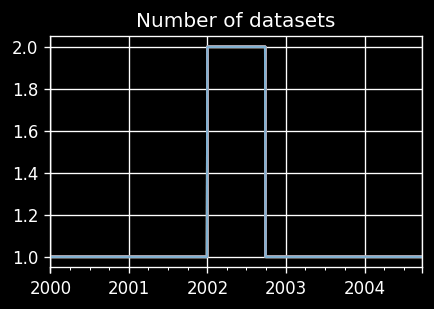

** ACCEPT STRATEGY from normal approximation of bootstrap Sharpe [alpha = 5e-05]**


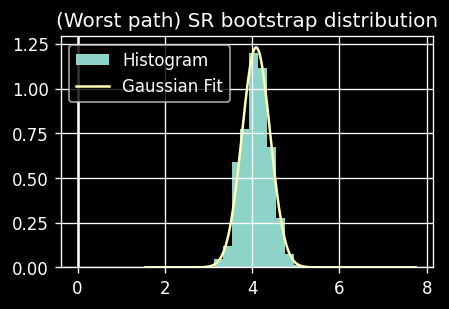


** PERFORMANCE SUMMARY **

Return:  28.80688038639665
Standard deviation:  7.071188016034063
Sharpe:  4.073838840245297



,path_1,path_2,path_3,path_4,path_5
1999-12-31,0.002830,0.003283,0.003210,0.003037,0.002743
2000-01-03,0.034749,0.026416,0.028241,0.030375,0.036530
2000-01-04,-1.569156,-1.569156,-1.569156,-1.569156,-1.569156
2000-01-05,-0.066783,-0.013406,-0.024163,-0.039767,-0.077894
2000-01-06,0.239907,0.258973,0.256088,0.247887,0.236591
...,...,...,...,...,...
2004-09-20,0.636047,0.620860,0.641549,0.645059,0.655103
2004-09-21,-0.004460,-0.007878,-0.003695,0.003559,0.003871
2004-09-22,0.380475,0.371712,0.383677,0.385568,0.391410
2004-09-23,0.158343,0.158475,0.158278,0.158588,0.158241


In [8]:
paths.portfolio_post_process(pct_fee = 0)
